In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas
from matplotlib import pyplot as plt

(null): No such file or directory


In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() == True else 'cpu'
torch.set_default_device(device)
g = torch.Generator(device=device)

print(f"Using device '{device}'")

Using device 'cuda'


(null): No such file or directory


# DataLoaders
When was this? I forgot.

The following section initialises the data.

1. The data is sliced into train, validation, and test sets
2. The "Dataset" class is built to return a length of shape `X.shape[0]`. It then returns the items `X[index]` and `Y[index]` when called on by `DataLoader`.
3. The `DataLoader` classes are eventually used as inputs to the model.

In [4]:
data = torch.from_numpy(pandas.read_csv('../../data/train.csv').to_numpy())

X_train = data[:30000,1:].float().reshape(-1,28,28) / 255
y_train = data[:30000,0]

X_val = data[30000:36000,1:].float().reshape(-1,28,28) / 255
y_val = data[30000:36000,0]

X_test = data[36000:42000,1:].float().reshape(-1,28,28) / 255
y_test = data[36000:42000,0]

2026-07-29 The next step is to move this data to the gpu memory. I'm running this on apple silicon, so I'm not sure what the difference is. But I have a computer that will definitely care.

2026-07-30 me here: This is just because I'm using X_train to test data rather than using the dataloader class. I have now rectified that, pulling the first data from the class using `images, labels = next(iter(train_loader))`

In [5]:
X_train = X_train.to(device)

In [6]:
class Dataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self,index):
        return self.X[index], self.y[index]

In [7]:
dataset_train = Dataset(X_train, y_train)
dataset_val = Dataset(X_val, y_val)
dataset_test = Dataset(X_test, y_test)

dataloader_train = DataLoader(dataset_train, batch_size=100, shuffle=True, generator=g)
dataloader_val = DataLoader(dataset_val, batch_size=100, shuffle=False)
dataloader_test = DataLoader(dataset_test, batch_size=100, shuffle=False)

# nn.Module classes
Classes created with this in mind serve as the basis of the neural networks. I will not be using those. Instead, I will do my best to code a cnn mostly from scratch.

**2026-07-30**
I think I wrote this code yersterday?

I'm not actually sure what this code does. I forgot to write what it does here. Oh well. But from what I can see,

1. First, initialises the tensor output of the convolution, with shape `(h-2, w-2)` compared to the input
2. Creates loops i,j to cycle between 1 more and 1 less than the minimum and maximum values. This serves as 'padding' of sorts for the code.
3. It then uses those values to grab the 3x3 square immediately around it. This is my understanding of what a convole is.
4. Loops through all that
5. Returns the outputs.

In [8]:
input_image = X_train[1]
kernel = torch.tensor([
    [1,1,1],
    [0,0,0],
    [1,1,1],
]).float()

def convolution(input_image,kernel):
    outputs = torch.zeros(input_image.shape[0]-2,input_image.shape[1]-2)

    print(f"input_image: {input_image}, {input_image.shape}")
    print(f"kernel: {kernel}, {kernel.shape}")
    for i in range(1,input_image.shape[0]-1):
        for j in range(1, input_image.shape[1]-1):
            outputs[i-1,j-1] = torch.sum((input_image[i-1:i+2,j-1:j+2] * kernel))

    return outputs

input_image: tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0

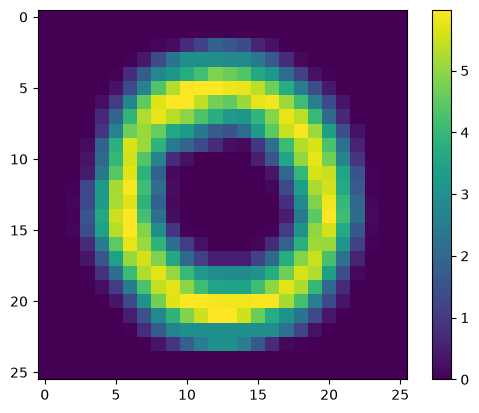

In [9]:
output1 = convolution(input_image,kernel)

output1_plot = output1.detach().cpu().numpy()
plt.imshow(output1_plot, cmap='viridis')
plt.colorbar()
plt.show()

**2026-07-30**
The code above works, but is painfully slow. This is because it iterates through the loop a couple hundred times to compute a small amount of maths. The natural next step would be to vectorise it.

The one below kind of works, but also doesn't work very well. But hey, you gotta make it exist (sligthly more) before making it good.

In this case, what I wanted to do here is to implement im2col to reduce the number of calls made to the gpu. Even though there is still a lot of looping, it is much faster as only one call is made to the gpu.

This code:
1. The loops `i,j` find the right patch, and defines the `patch` variable. This currently only works for a 3x3 kernel, though I am trying to fix that in the next version.
2. The loops `k,l` reshape the (3,3) matrix into a (9,1) vector(?). This is put in the `col_image` a column of the `col_image` variable, which lays them out as a column.
3. The kernel is then reshaped from a (3,3) matrix into a (9,1) vector(?) to ensure the correct dimensions for matmul. This is stored in the `col_kernel` variable.
4. Everything is matrix multiplied.

Improvements to be made:
1. Right now, stride does nothing. I will improve that in the next version.
2. Everything is hard-coded. It shouldn't be hardcoded.
3. My friend said something about classes. Maybe I should implement that.

In [10]:
input_image = X_train[1]
kernel = torch.tensor([
    [1,1,1],
    [0,0,0],
    [1,1,1],
]).float()
stride = 1

def vectorised_convolution(input_image, kernel, stride):
    # im2col
    col_image = torch.zeros((kernel.shape[0] * kernel.shape[1],676))
    m = -1
    for i in range(1,input_image.shape[0]-1):
        for j in range(1, input_image.shape[1]-1):
            patch = input_image[i-1:i+2,j-1:j+2]
            m += 1
            for k in range(kernel.shape[0]):
                for l in range(kernel.shape[1]):
                    col_image[k*3 + l, m] = patch[k,l]
    print(col_image)

    # kernel to col
    col_kernel = kernel.reshape(9,1)
    
    # matmul
    var_convolution = col_kernel.T @ col_image
    print(var_convolution)
                    
vectorised_convolution(input_image, kernel, stride)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,


Now, I know that vectorised functions run much faster than those that aren't vectorised. So taht's exactly what I will be doing.

**2026-07-30**
I wrote this code just then.

Is there that much of a point in writing this many 'iteration' reviews? I don't think so. I might write something when I do something big.

**2026-07-31**
I have come to the realisation that I should probably write what this code does.

This code:
1. Initialises the variable col_image, which is the output size of my im2col algorithm. This is calculated using the dimensions of the `input_image` and `kernel`, as well as the `stride`.
2. The im2col algorithm creates a sliding window of the size of the kernel, indexed from the top left. This is a fully parametric operation, being dependent on the shape of the kernel as well as the size of the image. This is a large improvement from before, as any size image can now be inputted without manually adjusting the code. By iterating `m`, I transform the `input_image` into a matrix.
3. The kernel is reshaped into a column vector, which is then matmul(ed)(?) with `col_image`.
4. The output is returned in matrix form.

My friend also said that I should commit more frequently. So I will.

My end goal is to make a CNN for MNIST from scratch, if it wasn't obvious from the dataset that I imported. So there's a lot of improvements to be made.

Improvements to be made:
1. My friend said something about classes. Maybe I should implement that.
2. Generalise to multiple channels/filters.
3. Bias term.
4. Non-linearity
5. Back propagation
6. Flatten + connect to existing dense layers.
7. Training loop

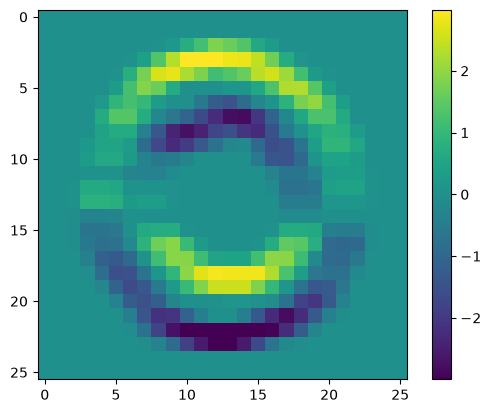

In [11]:
input_image = X_train[1]
kernel = torch.tensor([
    [-1,-1,-1],
    [0,0,0],
    [1,1,1],
]).float()
stride = 1

def convolution(input_image, kernel, stride):
    # im2col
    col_image = torch.zeros((kernel.shape[0] * kernel.shape[1], ((input_image.shape[0]-kernel.shape[0]) // stride+1) * ((input_image.shape[1]-kernel.shape[1]) // stride+1)))
    m = 0
    for i in range(0, input_image.shape[0]-kernel.shape[0]+1, stride):
        for j in range(0, input_image.shape[1]-kernel.shape[1]+1, stride):
            patch = input_image[i:i+kernel.shape[0],j:j+kernel.shape[1]]
            col_image[:,m] = patch.reshape(kernel.shape[0] * kernel.shape[1])
            m += 1

    # kernel to col
    col_kernel = kernel.reshape(kernel.shape[0] * kernel.shape[1],1)
    
    # matmul
    output = col_kernel.T @ col_image
    output_data = output.reshape(((input_image.shape[0]-kernel.shape[0]) // stride+1, (input_image.shape[1]-kernel.shape[1]) // stride+1))
    return output_data

output_data = convolution(input_image, kernel, stride).detach().cpu().numpy()
plt.imshow(output_data, cmap='viridis')
plt.colorbar()
plt.show()

**2026-07-31**
This one doesn't work. I gave up. Let's go follow a tutorial!

I now know why it wasn't working. I forgot to use an activation function ;-;

Anyways, what this code does is:
1. Defines the `prewitt_horizontal` and `prewitt_vertical` variables
2. Defines an **ACTIVATION FUNCTION** that was probably important last time...
3. I think all the rest of the code is the same. 

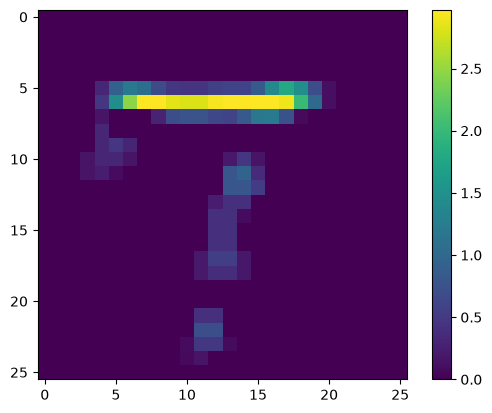

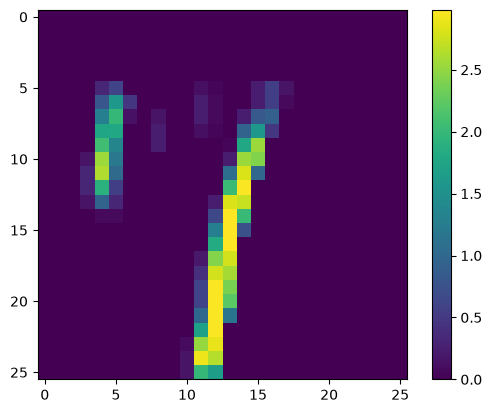

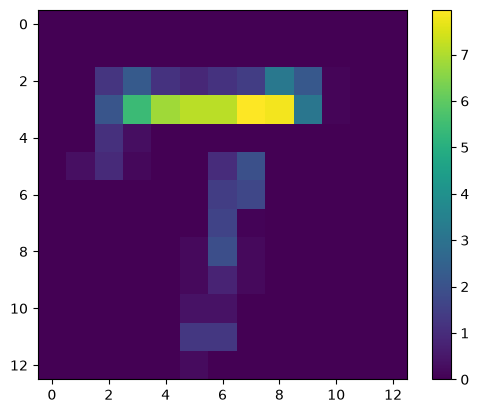

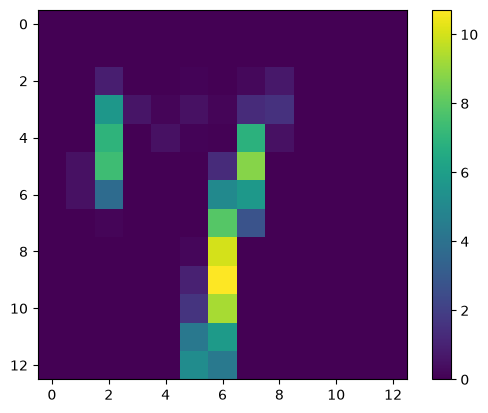

In [49]:
# activation functions
def ReLU(pre_activations):
    return torch.clamp(pre_activations,min=0)

def convolution(input_image, kernel, stride):
    # im2col
    col_image = torch.zeros((kernel.shape[0] * kernel.shape[1], ((input_image.shape[0]-kernel.shape[0]) // stride+1) * ((input_image.shape[1]-kernel.shape[1]) // stride+1)))
    m = 0
    for i in range(0, input_image.shape[0]-kernel.shape[0]+1, stride):
        for j in range(0, input_image.shape[1]-kernel.shape[1]+1, stride):
            patch = input_image[i:i+kernel.shape[0],j:j+kernel.shape[1]]
            col_image[:,m] = patch.reshape(kernel.shape[0] * kernel.shape[1])
            m += 1

    # kernel to col
    col_kernel = kernel.reshape(kernel.shape[0] * kernel.shape[1],1)
    
    # matmul
    col_pre_activations = col_kernel.T @ col_image
    pre_activations = col_pre_activations.reshape(((input_image.shape[0]-kernel.shape[0]) // stride+1, (input_image.shape[1]-kernel.shape[1]) // stride+1))

    activations = ReLU(pre_activations)
    return activations

# max pool layer
def max_pool(input_image, kernel, stride):

    pool = torch.zeros((
        ((input_image.shape[0]-kernel.shape[0]) // stride + 1),
        ((input_image.shape[1]-kernel.shape[1]) // stride + 1)
    ))
    print(pool.shape)

    # pooling
    for i in range(0, input_image.shape[0]-kernel.shape[0]+1, stride):
        for j in range(0, input_image.shape[1]-kernel.shape[1]+1, stride):
            oi, oj = int(i / stride), int(j / stride)
            print(oi,oj)
            patch = input_image[i:i+kernel.shape[0],j:j+kernel.shape[1]]
            pool[oi,oj] = torch.max(patch)

    return pool

# not function definitions
input_image = X_train[6]
kernel_v = torch.tensor([
    [-1,-1,-1],
    [0,0,0],
    [1,1,1],
]).float()
kernel_h = torch.tensor([
    [-1,0,1],
    [-1,0,1],
    [-1,0,1]
]).float()
stride = 1

pool_kernel = torch.ones((2,2))

def run_function(function_name, input_image, kernel, stride):
    function = globals()[function_name]
    output = function(input_image, kernel, stride)

    # plot the function
    plt.imshow(output.cpu().numpy(), cmap='viridis')
    plt.colorbar()
    plt.show()

    return output

a1l1 = run_function("convolution", input_image, kernel_v, stride=1)
a2l1 = run_function("convolution", input_image, kernel_h, stride=1)

p1l1 = run_function("convolution", a1l1, pool_kernel, stride=2)
p2l1 = run_function("convolution", a2l1, pool_kernel, stride=2)